/Applications/anaconda3/envs/Parth_1/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 0.23.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Applications/anaconda3/envs/Parth_1/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 0.22.2.post1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Patching model 'Air-Cooled Chiller GP': Restoring missing normalization attributes...

Loading Weather Data...
Successfully loaded '../madison_weather.xlsx'
Starting Simulation...

Post-Processing: Replacing 0 values with minimum non-zero values...
  > Replaced 0s in a column with 0.019491
  > Replaced 0s in a column with 0.017720

Simulation Complete. Results:
    Month  PUE_Case1  WUE_Case1  PUE_Case6  WUE_Case6
0     1.0   1.036211   0.113788   1.264164    0.01772
1     2.0   1.036210   0.110956   1.266818    0.01772
2     3.0   1.031375   0.019491   1.294141    0.01772
3     4.0   1.031424   0.019491   1.151221    0.01772
4     5.0   1.031402   0.019491   1.151252    0.01772
5     6.0   1.210627   2.987754   1.151876    0.01772
6     7.0   1.216299   3.004842   1.152082    0.01772
7     8.0   1.214565   2.999943   1.151914    0.01772
8     9.0   1.206104   2.975261   1.151269    0.01772
9    10.0   1.031379   0.019491   1.151155    0.01772
10   11.0   1.031365   0.019491   1.303417

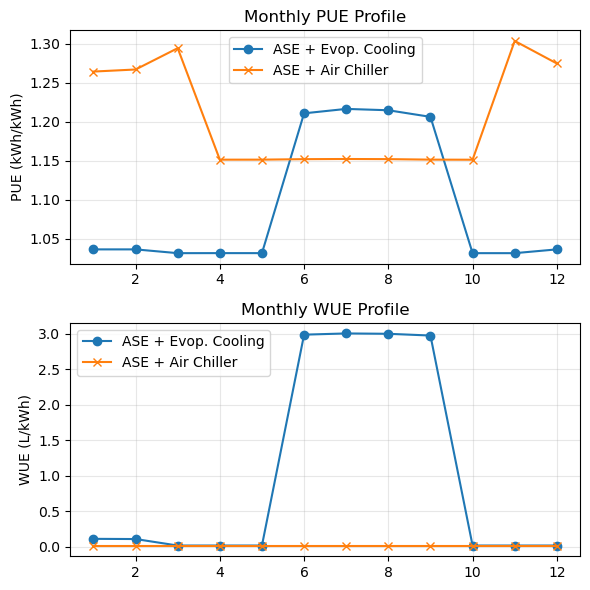

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys

# Import the specific functions AND the module itself to patch the variables
import simulation_funs_DC
from simulation_funs_DC import PUE_WUE_AE_Chiller, PUE_WUE_AE_AIRChiller

# ==========================================
# 1. FIX MODEL VERSION ERROR (The Patch)
# ==========================================
def patch_sklearn_model(model, name):
    """
    Fixes 'AttributeError: has no attribute _y_train_std' caused by 
    loading old scikit-learn models (v0.23) into newer environments (v1.x+).
    """
    # Check if the critical attributes used for normalization are missing
    if not hasattr(model, '_y_train_std'):
        print(f"Patching model '{name}': Restoring missing normalization attributes...")
        
        # In older sklearn, these might be stored with trailing underscores 
        # or we default to 1.0 (no scaling) if they are completely gone.
        if hasattr(model, 'y_train_std_'):
            model._y_train_std = model.y_train_std_
            model._y_train_mean = model.y_train_mean_
        else:
            # Fallback: Assume no normalization was applied or force unity
            model._y_train_std = 1.0
            model._y_train_mean = 0.0

# Apply the patch to the three loaded models inside the module
patch_sklearn_model(simulation_funs_DC.COP_gp, "Water-Cooled Chiller GP")
patch_sklearn_model(simulation_funs_DC.COP_air_gp, "Air-Cooled Chiller GP")
patch_sklearn_model(simulation_funs_DC.COP_DX_gp, "DX System GP")

# ==========================================
# 2. LOAD DATA
# ==========================================
print("\nLoading Weather Data...")
try:
    # Looks for file in the parent folder
    df = pd.read_excel('../madison_weather.xlsx') 
    print("Successfully loaded '../madison_weather.xlsx'")
except FileNotFoundError:
    print("ERROR: Could not find '../madison_weather.xlsx'.")
    print("Please check that the file exists in the folder above this script.")
    sys.exit() # Stop execution if file is missing

# ==========================================
# 3. DEFINE INPUT PARAMETERS (Best Practice)
# ==========================================

# CASE 1: Large-scale, Airside Economizer + Adiabatic + Water-Cooled Chiller
w_case1_base = [
    0, 0, 0,        # [0-2] Weather (Temp, RH, P) - Updated in loop
    0.99,           # [3] UPS_e (99%)
    0.0,            # [4] PD_lr (0%)
    0.002,          # [5] L_percentage (0.2%)
    13.9,           # [6] delta_T_air
    300,            # [7] Fan_Pressure_CRAC
    0.90,           # [8] Fan_e_CRAC
    6300,           # [9] Pump_Pressure_HD
    0.80,           # [10] Pump_e_HD
    2.8,            # [11] AT_CT 
    0.8,            # [12] Chiller_load
    5,              # [13] delta_T_water
    114.9,          # [14] Pump_Pressure_CW
    0.80,           # [15] Pump_e_CW
    4,              # [16] delta_T_CT
    166.9,          # [17] Pump_Pressure_CT
    0.80,           # [18] Pump_e_CT
    0.005,          # [19] Windage_p
    15,             # [20] CC (Cycles of Concentration)
    100,            # [21] Fan_Pressure_CT
    0.90,           # [22] Fan_e_CT
    0.99,           # [23] SHR
    0.2,            # [24] LGRatio
    27,             # [25] T_up 
    18,             # [26] T_lw
    15,             # [27] dp_up
    -12,            # [28] dp_lw
    60,             # [29] RH_up
    20,             # [30] RH_lw
    -0.11           # [31] pcop
]

# CASE 6: Midsize, Airside Economizer + Air-Cooled Chiller
w_case6_base = [
    0, 0, 0,        # [0-2] Weather - Updated in loop
    0.94,           # [3] UPS_e (94%)
    0.02,           # [4] PD_lr (2%)
    0.02,           # [5] L_percentage (2%)
    10,             # [6] delta_T_air
    400,            # [7] Fan_Pressure_CRAC
    0.80,           # [8] Fan_e_CRAC
    0.99,           # [9] SHR
    6300,           # [10] Pump_Pressure_HD
    0.80,           # [11] Pump_e_HD
    10,             # [12] HTE
    10,             # [13] delta_T_water
    114.9,          # [14] Pump_Pressure_CW
    0.80,           # [15] Pump_e_CW
    -0.40,          # [16] pcop
    0.5,            # [17] Chiller_load
    32,             # [18] T_up
    18,             # [19] T_lw
    27,             # [20] dp_up
    -12,            # [21] dp_lw
    80,             # [22] RH_up
    30              # [23] RH_lw
]

# ==========================================
# 4. RUN SIMULATION
# ==========================================

results = []

# Suppress warnings about "divide by zero" (occurs in winter when water flow is 0)
# and the sklearn version warning (since we patched it)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

print("Starting Simulation...")

for index, row in df.iterrows():
    # Extract weather from the current row
    T_oa = row['Dry_Bulb_Temp (C)']
    RH_oa = row['Relative_Humidity (%)']
    P_oa = row['Pressure (Pa)']
    
    current_weather = [T_oa, RH_oa, P_oa]
    
    # --- Run Case 1 ---
    w1 = current_weather + w_case1_base[3:] 
    pue1, wue1 = PUE_WUE_AE_Chiller(w1)
    
    # --- Run Case 6 ---
    w6 = current_weather + w_case6_base[3:]
    pue6, wue6 = PUE_WUE_AE_AIRChiller(w6)
    
    results.append({
        'Month': row['Month'],
        'PUE_Case1': pue1,
        'WUE_Case1': wue1,
        'PUE_Case6': pue6,
        'WUE_Case6': wue6
    })

res_df = pd.DataFrame(results)



# ==========================================
# 5. POST-PROCESSING (REPLACE ZEROS)
# ==========================================
print("\nPost-Processing: Replacing 0 values with minimum non-zero values...")

# Function to replace 0 with min non-zero
def replace_zeros_with_min(column):
    # Find minimum value that is strictly greater than 0
    non_zero_min = column[column > 0].min()
    
    # Check if a valid min exists (in case ALL are 0)
    if pd.notna(non_zero_min):
        # Replace 0s with that minimum
        column = column.replace(0, non_zero_min)
        print(f"  > Replaced 0s in a column with {non_zero_min:.6f}")
    else:
        print("  > Warning: Column has no non-zero values. Zeros kept.")
    return column

# Apply to both WUE columns
res_df['WUE_Case1'] = replace_zeros_with_min(res_df['WUE_Case1'])
res_df['WUE_Case6'] = replace_zeros_with_min(res_df['WUE_Case6'])


print("\nSimulation Complete. Results:")
print(res_df)

# ==========================================
# 5. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# PUE Plot
ax1.plot(res_df['Month'], res_df['PUE_Case1'], marker='o', label='ASE + Evop. Cooling')
ax1.plot(res_df['Month'], res_df['PUE_Case6'], marker='x', label='ASE + Air Chiller')
ax1.set_title('Monthly PUE Profile')
ax1.set_ylabel('PUE (kWh/kWh)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# WUE Plot
ax2.plot(res_df['Month'], res_df['WUE_Case1'], marker='o',  label='ASE + Evop. Cooling')
ax2.plot(res_df['Month'], res_df['WUE_Case6'], marker='x',  label='ASE + Air Chiller')
ax2.set_title('Monthly WUE Profile')
ax2.set_ylabel('WUE (L/kWh)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [2]:
# # ==========================================
# # 5. SAVE TO EXCEL (New Step)
# # ==========================================
# output_filename = 'PUE_WUE_Madison_Results.xlsx'
# print(f"\nSaving results to {output_filename}...")
# res_df.to_excel(output_filename, index=False)
# print("Done! File saved successfully.")


Loading Hourly Weather Data from: ../Hourly_Weather.xlsx...
Successfully loaded 8760 rows.
Starting Hourly Simulation (this may take a moment)...

Post-Processing: Replacing 0 values with minimum non-zero values...
  > Replaced 4455 zeros with 0.000071
  > Replaced 4570 zeros with 0.000000

Saving detailed results to Hourly_PUE_WUE_Results.xlsx...
Done! File saved successfully.

Generating Plots...


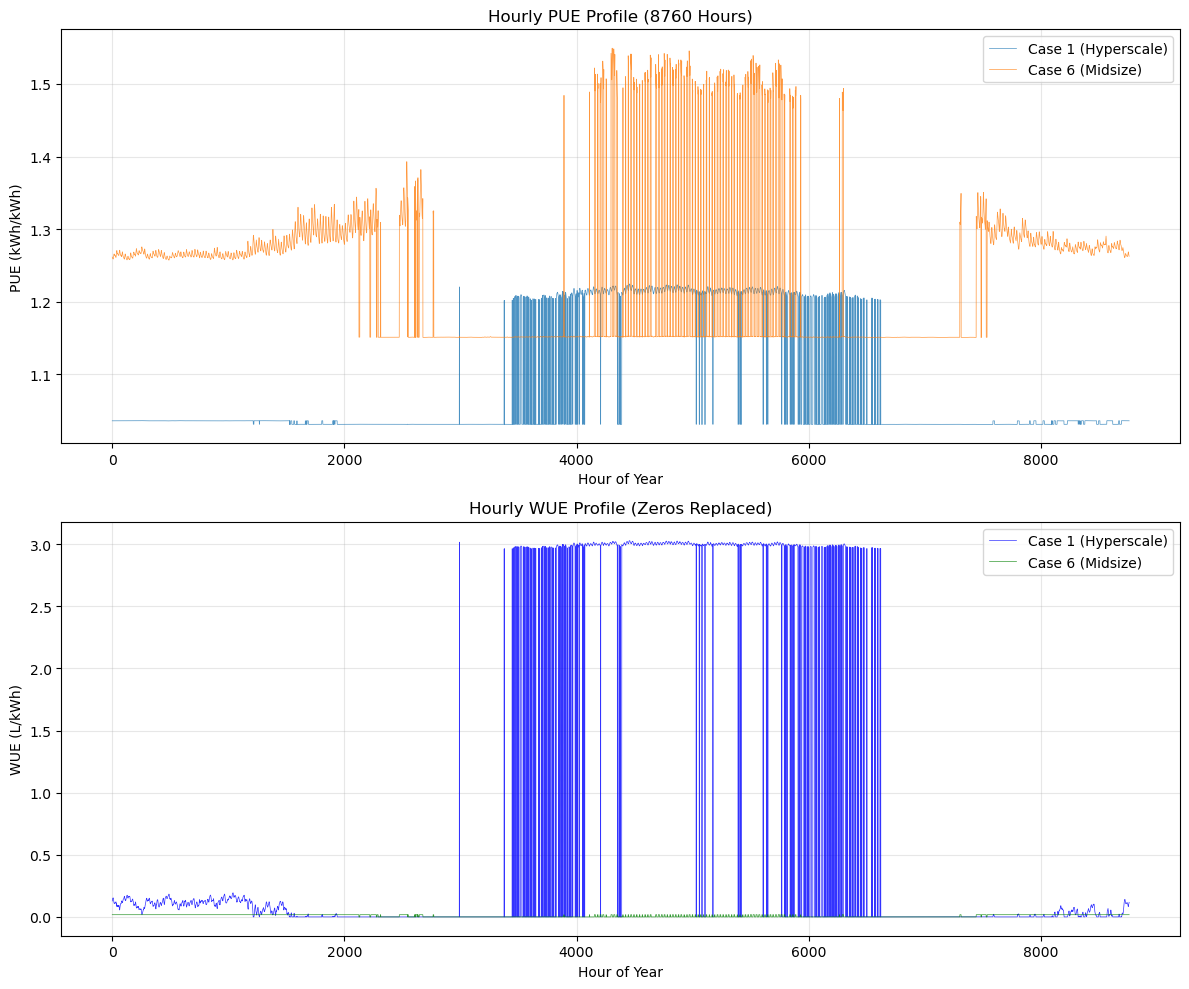

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
import os

# Import the specific functions AND the module itself to patch the variables
import simulation_funs_DC
from simulation_funs_DC import PUE_WUE_AE_Chiller, PUE_WUE_AE_AIRChiller

# ==========================================
# 1. FIX MODEL VERSION ERROR (The Patch)
# ==========================================
def patch_sklearn_model(model, name):
    """
    Fixes 'AttributeError: has no attribute _y_train_std' caused by 
    loading old scikit-learn models (v0.23) into newer environments (v1.x+).
    """
    if not hasattr(model, '_y_train_std'):
        if hasattr(model, 'y_train_std_'):
            model._y_train_std = model.y_train_std_
            model._y_train_mean = model.y_train_mean_
        else:
            model._y_train_std = 1.0
            model._y_train_mean = 0.0

patch_sklearn_model(simulation_funs_DC.COP_gp, "Water-Cooled Chiller GP")
patch_sklearn_model(simulation_funs_DC.COP_air_gp, "Air-Cooled Chiller GP")
patch_sklearn_model(simulation_funs_DC.COP_DX_gp, "DX System GP")

# ==========================================
# 2. LOAD HOURLY DATA
# ==========================================
input_weather_file = '../Hourly_Weather.xlsx'
print(f"\nLoading Hourly Weather Data from: {input_weather_file}...")

if not os.path.exists(input_weather_file):
    print(f"ERROR: Could not find '{input_weather_file}'.")
    print("Please ensure you ran the previous step to generate the hourly weather file.")
    sys.exit()

df = pd.read_excel(input_weather_file)
print(f"Successfully loaded {len(df)} rows.")

# ==========================================
# 3. DEFINE INPUT PARAMETERS (Best Practice)
# ==========================================

# CASE 1: Large-scale, Airside Economizer + Adiabatic + Water-Cooled Chiller
w_case1_base = [
    0, 0, 0,        # [0-2] Weather placeholders
    0.99, 0.0, 0.002, 13.9, 300, 0.90, 6300, 0.80, 2.8, 0.8, 5, 
    114.9, 0.80, 4, 166.9, 0.80, 0.005, 15, 100, 0.90, 0.99, 0.2, 
    27, 18, 15, -12, 60, 20, -0.11
]

# CASE 6: Midsize, Airside Economizer + Air-Cooled Chiller
w_case6_base = [
    0, 0, 0,        # [0-2] Weather placeholders
    0.94, 0.02, 0.02, 10, 400, 0.80, 0.99, 6300, 0.80, 10, 
    10, 114.9, 0.80, -0.40, 0.5, 32, 18, 27, -12, 80, 30
]

# ==========================================
# 4. RUN SIMULATION (8760 Hours)
# ==========================================
results = []

# Suppress warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

print("Starting Hourly Simulation (this may take a moment)...")

for index, row in df.iterrows():
    # Extract weather columns (Ensure names match your file)
    T_oa = row['Dry_Bulb_Temp (C)']
    RH_oa = row['Relative_Humidity (%)']
    P_oa = row['Pressure (Pa)']
    
    current_weather = [T_oa, RH_oa, P_oa]
    
    # --- Run Case 1 ---
    w1 = current_weather + w_case1_base[3:] 
    pue1, wue1 = PUE_WUE_AE_Chiller(w1)
    
    # --- Run Case 6 ---
    w6 = current_weather + w_case6_base[3:]
    pue6, wue6 = PUE_WUE_AE_AIRChiller(w6)
    
    # Store results including the input weather for reference
    results.append({
        'Hour_Sequence': row.get('Hour_Sequence', index + 1),
        'PUE_Case1': pue1, 'WUE_Case1': wue1,
        'PUE_Case6': pue6, 'WUE_Case6': wue6
    })

res_df = pd.DataFrame(results)

# ==========================================
# 5. POST-PROCESSING (REPLACE ZEROS)
# ==========================================
print("\nPost-Processing: Replacing 0 values with minimum non-zero values...")

def replace_zeros_with_min(column):
    # Find minimum value strictly > 0
    non_zero_min = column[column > 0].min()
    
    if pd.notna(non_zero_min):
        count_zeros = (column == 0).sum()
        column = column.replace(0, non_zero_min)
        print(f"  > Replaced {count_zeros} zeros with {non_zero_min:.6f}")
    return column

# Apply to WUE columns
res_df['WUE_Case1'] = replace_zeros_with_min(res_df['WUE_Case1'])
res_df['WUE_Case6'] = replace_zeros_with_min(res_df['WUE_Case6'])

# ==========================================
# 6. SAVE TO EXCEL
# ==========================================
output_filename = 'Hourly_PUE_WUE_Results.xlsx'
print(f"\nSaving detailed results to {output_filename}...")
# res_df.to_excel(output_filename, index=False)
print("Done! File saved successfully.")

# ==========================================
# 7. PLOTTING
# ==========================================
print("\nGenerating Plots...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# PUE Plot
ax1.plot(res_df['Hour_Sequence'], res_df['PUE_Case1'], label='Case 1 (Hyperscale)', linewidth=0.5, alpha=0.8)
ax1.plot(res_df['Hour_Sequence'], res_df['PUE_Case6'], label='Case 6 (Midsize)', linewidth=0.5, alpha=0.8)
ax1.set_title('Hourly PUE Profile (8760 Hours)')
ax1.set_ylabel('PUE (kWh/kWh)')
ax1.set_xlabel('Hour of Year')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# WUE Plot
ax2.plot(res_df['Hour_Sequence'], res_df['WUE_Case1'], color='blue', label='Case 1 (Hyperscale)', linewidth=0.5, alpha=0.8)
ax2.plot(res_df['Hour_Sequence'], res_df['WUE_Case6'], color='green', label='Case 6 (Midsize)', linewidth=0.5, alpha=0.8)
ax2.set_title('Hourly WUE Profile (Zeros Replaced)')
ax2.set_ylabel('WUE (L/kWh)')
ax2.set_xlabel('Hour of Year')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Generating 4 Stacked Plots...
Saving high-resolution plot to 'Hourly_PUE_WUE_HighRes.png'...


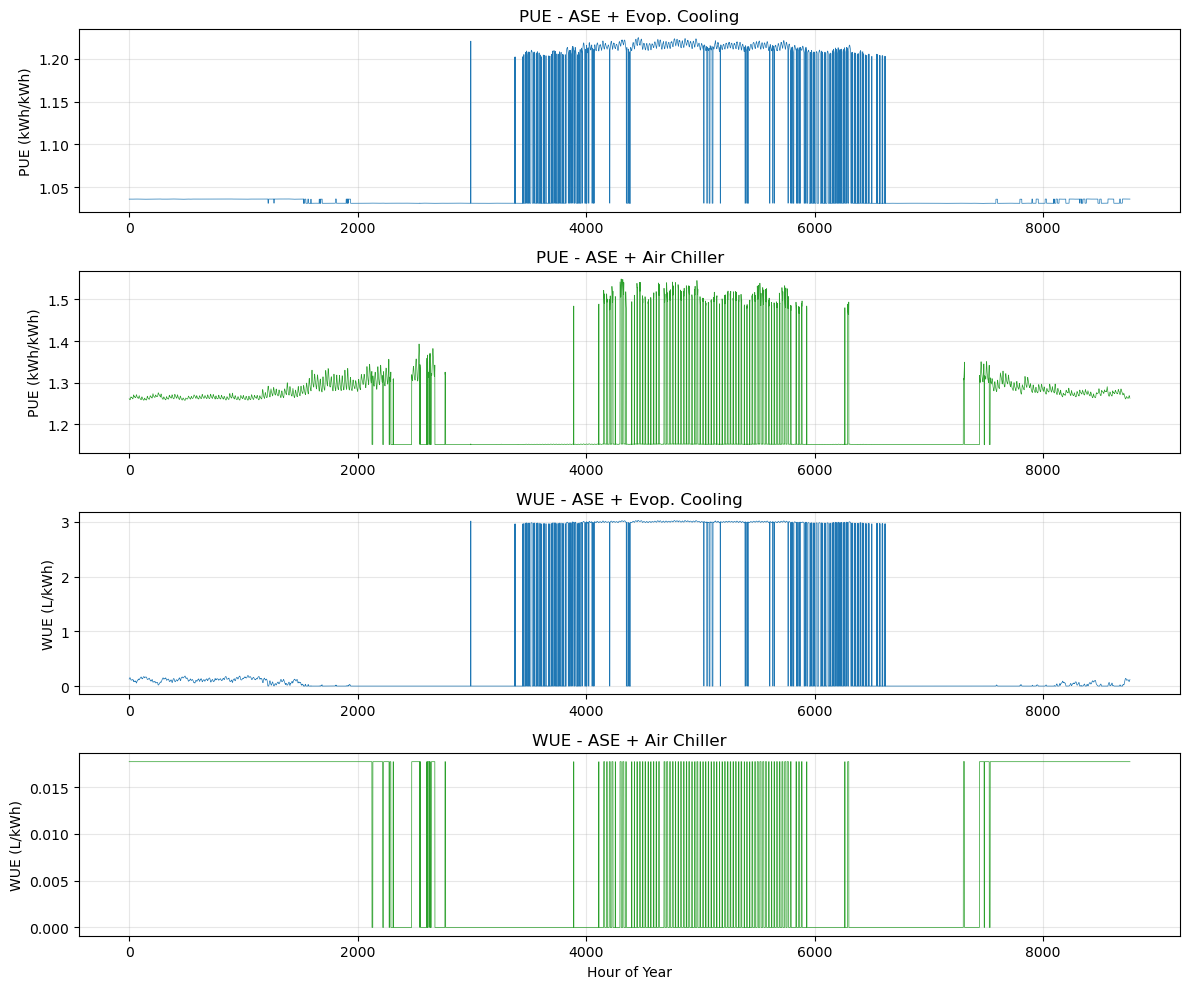

In [4]:
# ==========================================
# 7. PLOTTING (4 Rows x 1 Column)
# ==========================================
print("\nGenerating 4 Stacked Plots...")

# Create a figure with 4 rows and 1 column
# We increase the vertical size (height=16) to accommodate all 4 plots comfortably
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

# --- Plot 1: PUE Case 1 (Top) ---
axes[0].plot(res_df['Hour_Sequence'], res_df['PUE_Case1'], color='tab:blue', linewidth=0.5)
axes[0].set_title('PUE - ASE + Evop. Cooling')
axes[0].set_ylabel('PUE (kWh/kWh)')
axes[0].grid(True, alpha=0.3)

# --- Plot 2: PUE Case 6 ---
axes[1].plot(res_df['Hour_Sequence'], res_df['PUE_Case6'], color='tab:green', linewidth=0.5)
axes[1].set_title('PUE - ASE + Air Chiller')
axes[1].set_ylabel('PUE (kWh/kWh)')
axes[1].grid(True, alpha=0.3)

# --- Plot 3: WUE Case 1 ---
axes[2].plot(res_df['Hour_Sequence'], res_df['WUE_Case1'], color='tab:blue', linewidth=0.5)
axes[2].set_title('WUE - ASE + Evop. Cooling')
axes[2].set_ylabel('WUE (L/kWh)')
axes[2].grid(True, alpha=0.3)

# --- Plot 4: WUE Case 6 (Bottom) ---
axes[3].plot(res_df['Hour_Sequence'], res_df['WUE_Case6'], color='tab:green', linewidth=0.5)
axes[3].set_title('WUE - ASE + Air Chiller')
axes[3].set_ylabel('WUE (L/kWh)')
axes[3].set_xlabel('Hour of Year') # Only adding X-label to the bottom plot
axes[3].grid(True, alpha=0.3)

# Adjust layout to ensure titles and labels don't overlap
plt.tight_layout()
# --- SAVE COMMAND (600 DPI) ---
plot_filename = 'Hourly_PUE_WUE_HighRes.png'
print(f"Saving high-resolution plot to '{plot_filename}'...")
# plt.savefig(plot_filename, dpi=600, bbox_inches='tight')
plt.show()


Generating Hourly Heatmaps (Carpet Plots) with Time Shift and Gray Grid...
Saving high-resolution heatmap to 'Hourly_Heatmaps_PUE_WUE.pdf'...


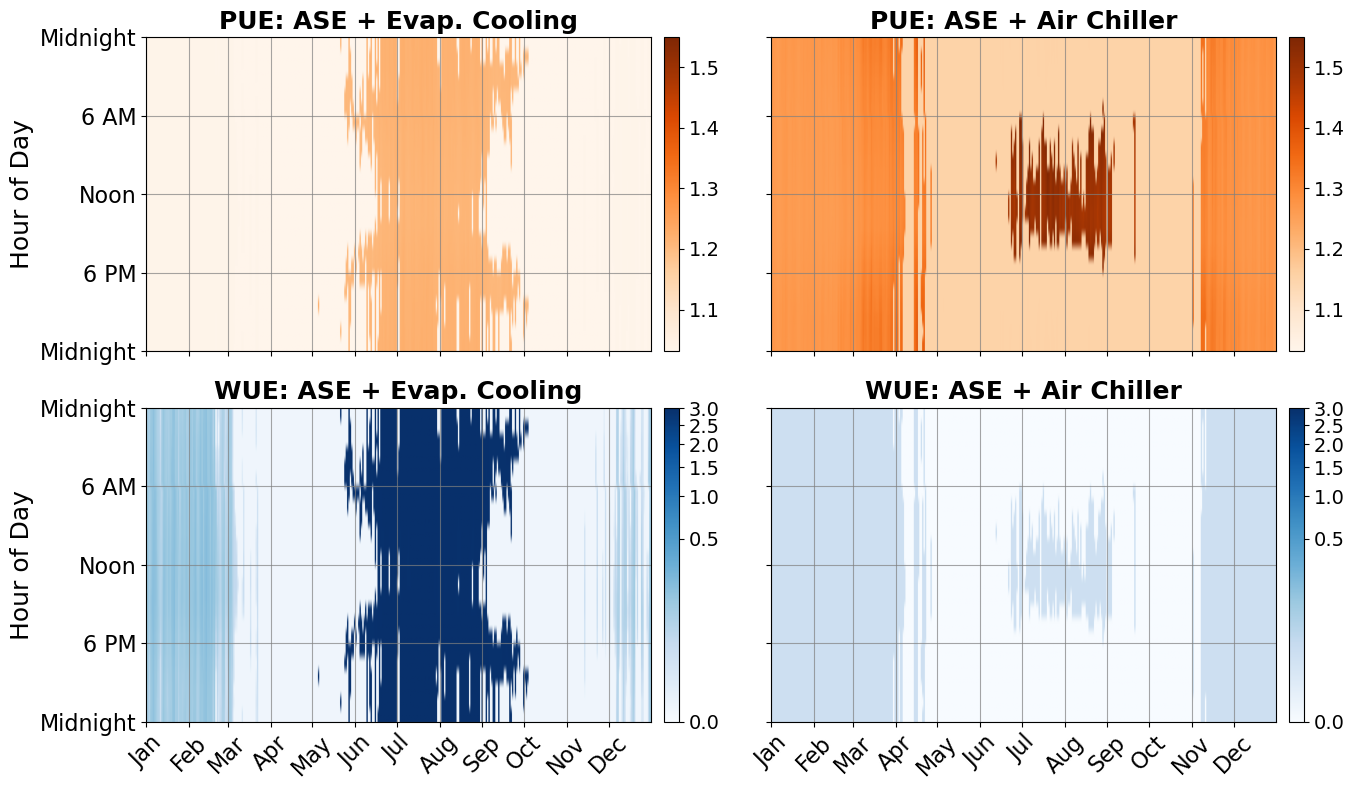

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

print("\nGenerating Hourly Heatmaps (Carpet Plots) with Time Shift and Gray Grid...")

# ==========================================
# --- CONFIGURATION SETTINGS ---
# Adjust this to fix your timezone offset! 
# Positive numbers shift the peak later into the day. Negative numbers shift it earlier.
TIME_SHIFT_HOURS = 6  

# Change these values to adjust your plot appearance
TITLE_FONTSIZE = 18      # Size of the subplot titles
LABEL_FONTSIZE = 18       # Size of the X and Y axis labels
TICK_FONTSIZE = 16       # Size of the axis tick labels (months, times)
CBAR_TICK_FONTSIZE = 14   # Size of the numbers on the colorbar
# ==========================================

# 1. Reshape the 8760-hour 1D arrays into 2D matrices (24 hours x 365 days)
# Note: .T transposes the matrix so hours (0-23) are on the rows and days (0-364) are on the cols
pue_evap_matrix = res_df['PUE_Case1'].values.reshape(365, 24).T
pue_air_matrix  = res_df['PUE_Case6'].values.reshape(365, 24).T
wue_evap_matrix = res_df['WUE_Case1'].values.reshape(365, 24).T
wue_air_matrix  = res_df['WUE_Case6'].values.reshape(365, 24).T

# Apply the Time Zone Shift (Rolls the Y-axis hours)
pue_evap_matrix = np.roll(pue_evap_matrix, shift=TIME_SHIFT_HOURS, axis=0)
pue_air_matrix  = np.roll(pue_air_matrix, shift=TIME_SHIFT_HOURS, axis=0)
wue_evap_matrix = np.roll(wue_evap_matrix, shift=TIME_SHIFT_HOURS, axis=0)
wue_air_matrix  = np.roll(wue_air_matrix, shift=TIME_SHIFT_HOURS, axis=0)

# 2. Calculate global min and max for shared color scales (The value limits)
pue_vmin = min(np.min(pue_evap_matrix), np.min(pue_air_matrix))
pue_vmax = max(np.max(pue_evap_matrix), np.max(pue_air_matrix))

wue_vmin = min(np.min(wue_evap_matrix), np.min(wue_air_matrix))
wue_vmax = max(np.max(wue_evap_matrix), np.max(wue_air_matrix))

# 3. Plotting Setup
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

# Helper function to plot individual heatmaps with bulletproof time axes
def plot_heatmap(ax, data_matrix, title, cmap, vmin=None, vmax=None, norm=None, ylabel='Hour of Day'):
    # extent=[left, right, bottom, top] forces the Y-axis to go from 24 (bottom) to 0 (top)
    extent = [0, 365, 24, 0]
    
    if norm is not None:
        im = ax.imshow(data_matrix, aspect='auto', cmap=cmap, origin='upper', extent=extent, norm=norm)
    else:
        im = ax.imshow(data_matrix, aspect='auto', cmap=cmap, origin='upper', extent=extent, vmin=vmin, vmax=vmax)
        
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE)
    
    # Lock ticks exactly to the visual grid layout reading Top-to-Bottom
    ax.set_yticks([0, 6, 12, 18, 24])
    ax.set_yticklabels(['Midnight', '6 AM', 'Noon', '6 PM', 'Midnight'])
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)
    
    # Force the gridlines to render ON TOP of the heatmap in GRAY
    ax.grid(True, which='major', color='gray', linestyle='-', linewidth=0.8, alpha=0.7, zorder=2)
    
    # Add a colorbar specifically for this subplot
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.ax.tick_params(labelsize=CBAR_TICK_FONTSIZE)
    return im

# --- TOP ROW: PUE ---
# Linear scale, Oranges colormap
plot_heatmap(axes[0, 0], pue_evap_matrix, 'PUE: ASE + Evap. Cooling', 'Oranges', vmin=pue_vmin, vmax=pue_vmax)
plot_heatmap(axes[0, 1], pue_air_matrix, 'PUE: ASE + Air Chiller', 'Oranges', vmin=pue_vmin, vmax=pue_vmax, ylabel='')

# --- BOTTOM ROW: WUE ---
# We use PowerNorm (gamma=0.3) to stretch the low-end colors so the Air Chiller (tiny values) is visible
wue_norm = mcolors.PowerNorm(gamma=0.3, vmin=wue_vmin, vmax=wue_vmax)

plot_heatmap(axes[1, 0], wue_evap_matrix, 'WUE: ASE + Evap. Cooling', 'Blues', norm=wue_norm)
plot_heatmap(axes[1, 1], wue_air_matrix, 'WUE: ASE + Air Chiller', 'Blues', norm=wue_norm, ylabel='')

# 4. Formatting the X-Axis to show approximate months instead of days 0-365
month_starts = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for ax in axes[1, :]:
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_names, rotation=45, ha='center', fontsize=TICK_FONTSIZE)
    ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)

plt.tight_layout()

# --- SAVE COMMAND ---
plot_filename = 'Hourly_Heatmaps_PUE_WUE.pdf'
print(f"Saving high-resolution heatmap to '{plot_filename}'...")
# plt.savefig(plot_filename, dpi=600, bbox_inches='tight')
plt.show()


Generating 4 Stacked Plots...
Saving high-resolution plot to 'Hourly_PUE_WUE_HighRes.png'...


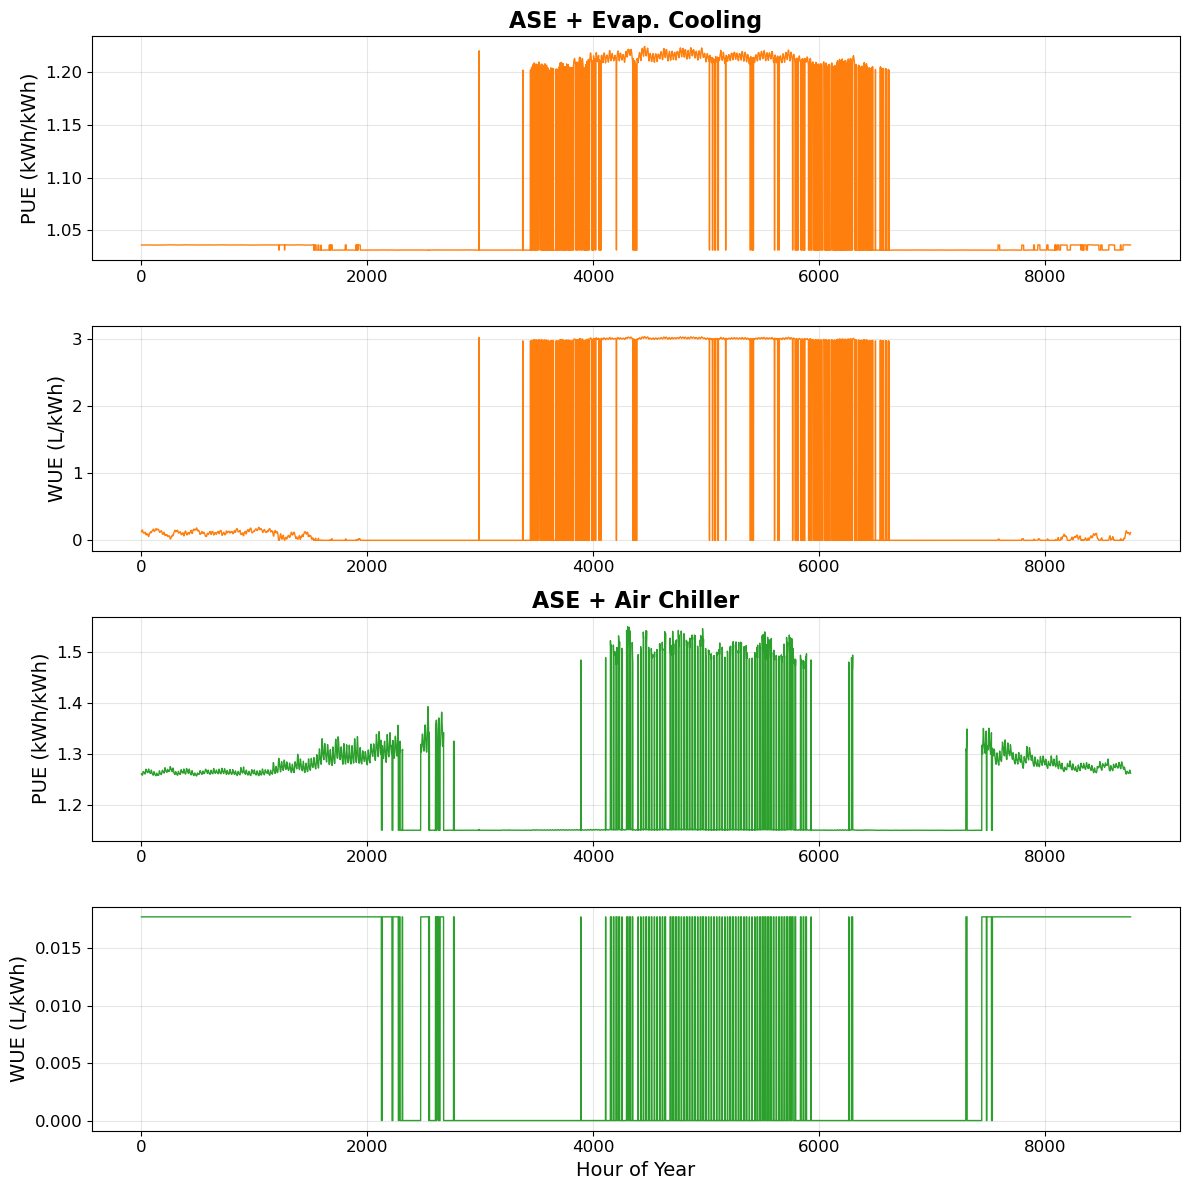

In [6]:
# ==========================================
# 7. PLOTTING (4 Rows x 1 Column)
# ==========================================
print("\nGenerating 4 Stacked Plots...")

# --- PLOT SETTINGS (Change these values to adjust your plot appearance) ---
LINE_WIDTH = 1.0          # Change line thickness here
TITLE_FONTSIZE = 16       # Change the size of the 2 main case titles
LABEL_FONTSIZE = 14       # Change the size of the X and Y axis labels
TICK_FONTSIZE = 12        # Change the size of the tick numbers
# --------------------------------------------------------------------------

# Create a figure with 4 rows and 1 column
fig, axes = plt.subplots(4, 1, figsize=(12, 12))

# ==========================================
# CASE 1: ASE + Evap. Cooling (Orange)
# ==========================================
# --- Plot 1: PUE ---
axes[0].plot(res_df['Hour_Sequence'], res_df['PUE_Case1'], color='tab:orange', linewidth=LINE_WIDTH)
axes[0].set_title('ASE + Evap. Cooling', fontsize=TITLE_FONTSIZE, fontweight='bold') # 1st Title here
axes[0].set_ylabel('PUE (kWh/kWh)', fontsize=LABEL_FONTSIZE)
axes[0].tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: WUE ---
axes[1].plot(res_df['Hour_Sequence'], res_df['WUE_Case1'], color='tab:orange', linewidth=LINE_WIDTH)
axes[1].set_ylabel('WUE (L/kWh)', fontsize=LABEL_FONTSIZE)
axes[1].tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE)
axes[1].grid(True, alpha=0.3)


# ==========================================
# CASE 2: ASE + Air Chiller (Green)
# ==========================================
# --- Plot 3: PUE ---
axes[2].plot(res_df['Hour_Sequence'], res_df['PUE_Case6'], color='tab:green', linewidth=LINE_WIDTH)
axes[2].set_title('ASE + Air Chiller', fontsize=TITLE_FONTSIZE, fontweight='bold') # 2nd Title here
axes[2].set_ylabel('PUE (kWh/kWh)', fontsize=LABEL_FONTSIZE)
axes[2].tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE)
axes[2].grid(True, alpha=0.3)

# --- Plot 4: WUE ---
axes[3].plot(res_df['Hour_Sequence'], res_df['WUE_Case6'], color='tab:green', linewidth=LINE_WIDTH)
axes[3].set_ylabel('WUE (L/kWh)', fontsize=LABEL_FONTSIZE)
axes[3].set_xlabel('Hour of Year', fontsize=LABEL_FONTSIZE) # Only adding X-label to the bottom plot
axes[3].tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE)
axes[3].grid(True, alpha=0.3)

# Adjust layout to ensure titles and labels don't overlap
plt.tight_layout()

# --- SAVE COMMAND (600 DPI) ---
plot_filename = 'Hourly_PUE_WUE_HighRes.png'
print(f"Saving high-resolution plot to '{plot_filename}'...")
# plt.savefig(plot_filename, dpi=600, bbox_inches='tight')
plt.show()


Generating 4 Stacked Plots...
Saving high-resolution plot to 'Hourly_PUE_WUE_HighRes.png'...


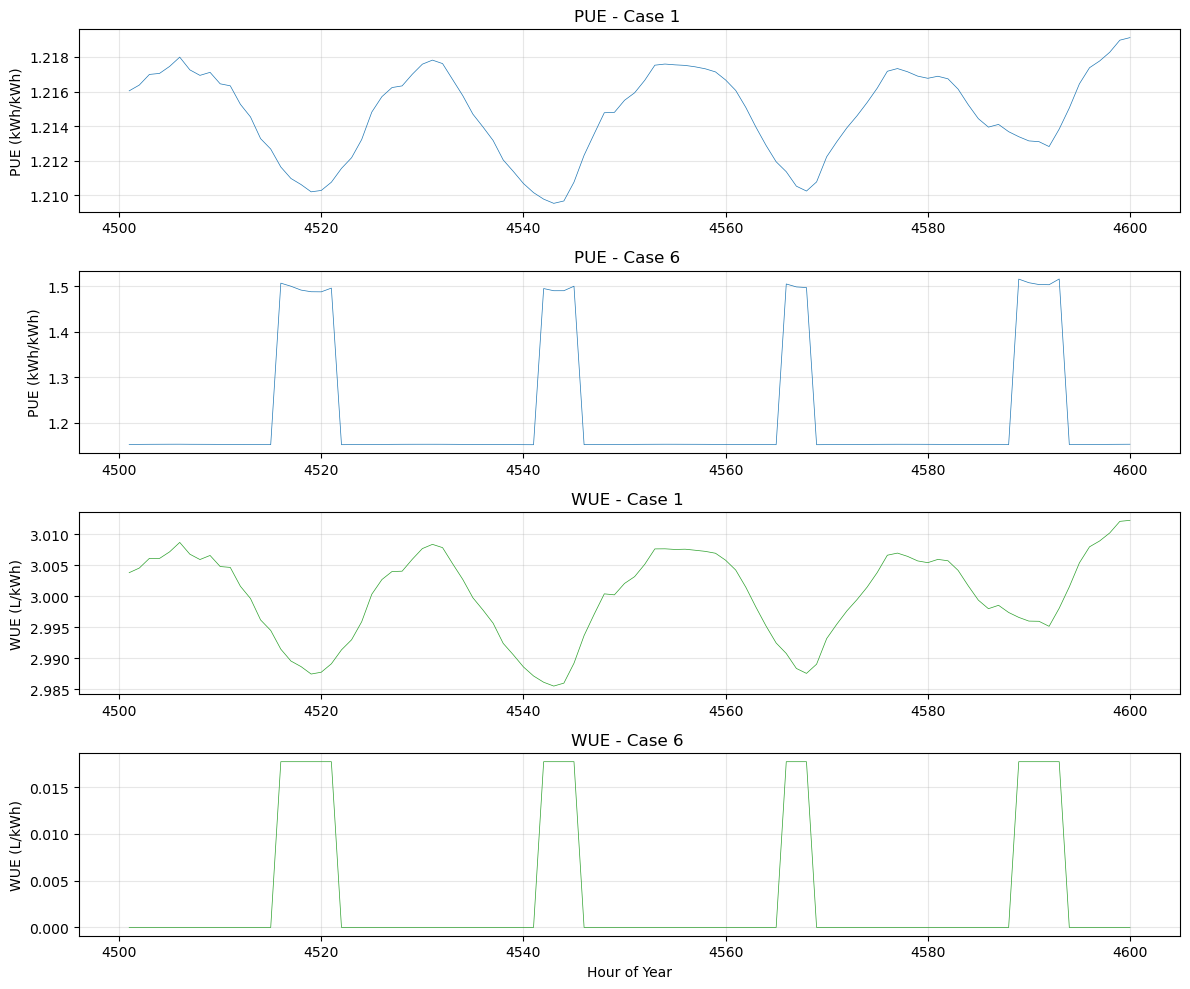

In [7]:
# ==========================================
# 7. PLOTTING (4 Rows x 1 Column)
# ==========================================
print("\nGenerating 4 Stacked Plots...")

# Create a figure with 4 rows and 1 column
# We increase the vertical size (height=16) to accommodate all 4 plots comfortably
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

# --- Plot 1: PUE Case 1 (Top) ---
axes[0].plot(res_df['Hour_Sequence'][4500:4600], res_df['PUE_Case1'][4500:4600], color='tab:blue', linewidth=0.5)
axes[0].set_title('PUE - Case 1 ')
axes[0].set_ylabel('PUE (kWh/kWh)')
axes[0].grid(True, alpha=0.3)

# --- Plot 2: PUE Case 6 ---
axes[1].plot(res_df['Hour_Sequence'][4500:4600], res_df['PUE_Case6'][4500:4600], color='tab:blue', linewidth=0.5)
axes[1].set_title('PUE - Case 6 ')
axes[1].set_ylabel('PUE (kWh/kWh)')
axes[1].grid(True, alpha=0.3)

# --- Plot 3: WUE Case 1 ---
axes[2].plot(res_df['Hour_Sequence'][4500:4600], res_df['WUE_Case1'][4500:4600], color='tab:green', linewidth=0.5)
axes[2].set_title('WUE - Case 1 ')
axes[2].set_ylabel('WUE (L/kWh)')
axes[2].grid(True, alpha=0.3)

# --- Plot 4: WUE Case 6 (Bottom) ---
axes[3].plot(res_df['Hour_Sequence'][4500:4600], res_df['WUE_Case6'][4500:4600], color='tab:green', linewidth=0.5)
axes[3].set_title('WUE - Case 6 ')
axes[3].set_ylabel('WUE (L/kWh)')
axes[3].set_xlabel('Hour of Year') # Only adding X-label to the bottom plot
axes[3].grid(True, alpha=0.3)

# Adjust layout to ensure titles and labels don't overlap
plt.tight_layout()
# --- SAVE COMMAND (600 DPI) ---
plot_filename = 'Hourly_PUE_WUE_HighRes.png'
print(f"Saving high-resolution plot to '{plot_filename}'...")
# plt.savefig(plot_filename, dpi=600, bbox_inches='tight')
plt.show()